2025/10/09 12:07:16 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing XGBoost using PSO...


2025/10/09 12:07:33 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7347738788371266, Global best: -0.7347738788371266, Runtime: 9.05102 seconds
2025/10/09 12:07:42 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7393182942072527, Global best: -0.7393182942072527, Runtime: 8.13809 seconds
2025/10/09 12:07:50 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7393182942072527, Global best: -0.7393182942072527, Runtime: 7.88721 seconds
2025/10/09 12:07:57 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7393182942072527, Global best: -0.7393182942072527, Runtime: 7.15127 seconds
2025/10/09 12:08:02 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7429600389645566, Global best: -0.7429600389645566, Runtime: 5.30621 seconds
2025/10/09 12:08:02 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.7430
PSO Best Params: {'n_estimators': 24, 'learning_rate': 0.422, 'max_depth': 6}

Optimizing XGBoost using GA...


2025/10/09 12:08:17 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 6.81190 seconds
2025/10/09 12:08:22 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 5.05020 seconds
2025/10/09 12:08:33 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 10.65403 seconds
2025/10/09 12:08:43 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 9.78079 seconds
2025/10/09 12:08:50 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7384150023483104, Global best: -0.7384150023483104, Runtime: 7.29369 seconds
2025/10/09 12:08:50 AM, INFO, mealpy.swarm_based.BA.OriginalBA: Origi

GA Accuracy: 0.7384
GA Best Params: {'n_estimators': 60, 'learning_rate': 0.297, 'max_depth': 9}

Optimizing XGBoost using Bat...


2025/10/09 12:09:12 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.736138135317345, Global best: -0.736138135317345, Runtime: 14.24397 seconds
2025/10/09 12:09:28 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.736138135317345, Global best: -0.736138135317345, Runtime: 15.41966 seconds
2025/10/09 12:09:43 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.7365947512157787, Global best: -0.7365947512157787, Runtime: 15.31135 seconds
2025/10/09 12:09:58 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.7375030130436836, Global best: -0.7375030130436836, Runtime: 15.18600 seconds
2025/10/09 12:10:14 AM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.7375030130436836, Global best: -0.7375030130436836, Runtime: 15.83845 seconds


Bat Accuracy: 0.7375
Bat Best Params: {'n_estimators': 94, 'learning_rate': 0.173, 'max_depth': 6}



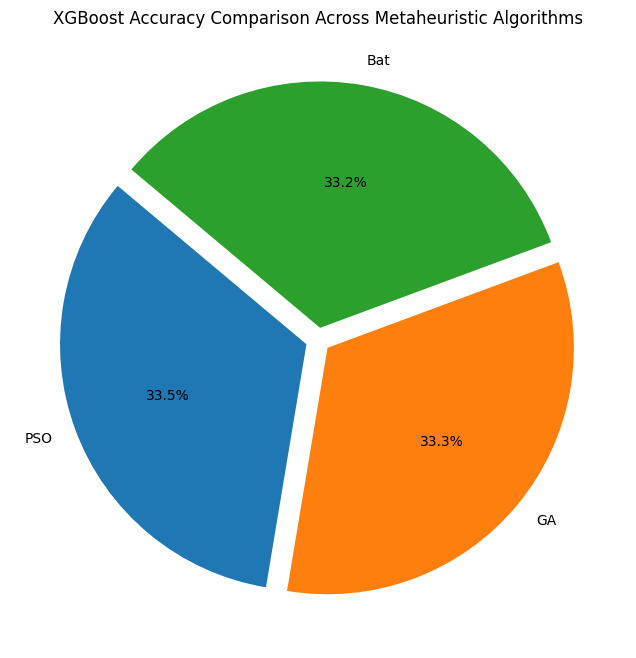

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
import xgboost as xgb
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# XGBoost Objective Function
# ----------------------------
def xgb_objective_function(solution):
    n_estimators = int(solution[0])
    learning_rate = solution[1]
    max_depth = int(solution[2])
    
    try:
        if n_estimators < 1:
            n_estimators = 50
        if learning_rate <= 0:
            learning_rate = 0.1
        if max_depth < 1:
            max_depth = 3
            
        model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42
        )
        scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# XGBoost Problem Definition
# ----------------------------
xgb_problem = {
    "bounds": [
        FloatVar(lb=10, ub=200, name="n_estimators"),      # Number of trees
        FloatVar(lb=0.01, ub=1.0, name="learning_rate"),  # Learning rate
        FloatVar(lb=1, ub=10, name="max_depth")           # Max depth of each tree
    ],
    "minmax": "min",
    "obj_func": xgb_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing XGBoost using {name}...")
    best_agent = optimizer.solve(xgb_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'n_estimators': int(best_solution[0]),
        'learning_rate': round(best_solution[1], 3),
        'max_depth': int(best_solution[2])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("XGBoost Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()
